# **Beginner Level — Superstore Sales Analysis**

## **Project Overview**

This project analyzes a retail sales dataset to understand sales performance, profitability, customer segments, product categories, regional performance, and trends over time. 

The objective is to transform raw transactional data into meaningful business insights and present the findings through an Excel-based dashboard.

The analysis follows the workflow:

Raw Data → Data Understanding → Data Cleaning → Exploratory Data Analysis → KPI Analysis → Business Insights → Excel Dashboard

---

## **Business Objective**

The objective of this analysis is to evaluate the overall sales and profitability performance of the business and identify important patterns across time, product categories, customer segments, and geographic regions.

The analysis will focus on questions such as:

- How much revenue is being generated?
- How profitable is the business?
- Which categories and sub-categories perform best?
- Which regions contribute the most sales and profit?
- How do sales and profit change over time?
- Which products or segments require attention?
- Are there areas where high sales do not translate into high profit?

The final findings will be used to create a business-oriented Excel dashboard and provide actionable recommendations.

---

## **Data Loading**

The dataset was loaded into a Pandas DataFrame using Python.

Pandas is used because it provides efficient data structures and functions for manipulating, inspecting, cleaning, and analyzing tabular data.

The loaded dataset is stored in the variable `df`, which will be used throughout the analysis.

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---

## **Data Inspection**

After loading the dataset, an initial inspection was performed to understand its structure, dimensions, data types, statistical characteristics, missing values, and duplicate records.

The following checks were performed:

- Dataset dimensions using `df.shape`
- Column names and data types using `df.info()`
- Statistical summary using `df.describe()`
- Missing-value detection using `df.isnull().sum()`
- Duplicate-record detection using `df.duplicated().sum()`

### Initial Observations

The dataset contains **10,194 records and 21 columns**.

All columns contain 10,194 non-null values, indicating that there are **no missing values** in the dataset.

The dataset contains:
- 2 datetime columns
- 3 floating-point columns
- 2 integer columns
- 1 object-type column for Postal Code
- 13 string/categorical columns

No duplicate rows were detected using `df.duplicated().sum()`.

The numerical summary also provides an initial understanding of the distribution and range of variables such as Sales, Quantity, Discount, and Profit.

These observations establish the initial quality and structure of the dataset before proceeding to data cleaning and preparation.

In [118]:
df = pd.read_excel("../data/superstore_sales.xls")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [119]:
df.shape

(10194, 21)

In [120]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  str           
 6   Customer Name   10194 non-null  str           
 7   Segment         10194 non-null  str           
 8   Country/Region  10194 non-null  str           
 9   City            10194 non-null  str           
 10  State/Province  10194 non-null  str           
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  str           
 13  Product ID      10194 non-null  str           
 14  Category        10194 non-null  str           
 15  Sub-Category 

In [121]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002943,2025-05-03 10:52:45.626839,228.225854,3.791838,0.155385,28.673417
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115


In [122]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [123]:
df.duplicated().sum()

np.int64(0)

---

## **Data Cleaning & Preparation**

Data cleaning is the process of identifying and handling problems in a dataset that may affect the accuracy or reliability of analysis.

Although the initial inspection shows that the dataset contains no missing values or completely duplicated rows, additional validation is required before analysis.

The cleaning process will verify:

- Column names and formatting
- Data types
- Categorical values and unnecessary whitespace
- Date consistency
- Numerical values and their valid ranges
- Duplicate identifiers
- Logical consistency between related columns

The objective is not to modify valid data unnecessarily, but to ensure that the dataset is clean, consistent, and suitable for business analysis.

In [124]:
# Check columns names
df.columns = df.columns.str.strip() # Standardize
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [125]:
# Check categorical values
categorical_columns = [
    "Ship Mode",
    "Segment",
    "Country/Region",
    "Region",
    "Category",
    "Sub-Category"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())

print()
print(df[categorical_columns].nunique()) # Check the number of unique values


Ship Mode:
<StringArray>
['Standard Class', 'First Class', 'Second Class', 'Same Day']
Length: 4, dtype: str

Segment:
<StringArray>
['Consumer', 'Home Office', 'Corporate']
Length: 3, dtype: str

Country/Region:
<StringArray>
['United States', 'Canada']
Length: 2, dtype: str

Region:
<StringArray>
['Central', 'East', 'South', 'West']
Length: 4, dtype: str

Category:
<StringArray>
['Office Supplies', 'Furniture', 'Technology']
Length: 3, dtype: str

Sub-Category:
<StringArray>
[      'Paper',     'Binders',      'Labels',     'Storage',         'Art',
      'Chairs',   'Fasteners',      'Phones', 'Furnishings', 'Accessories',
   'Bookcases',   'Envelopes',  'Appliances',      'Tables',    'Supplies',
    'Machines',     'Copiers']
Length: 17, dtype: str

Ship Mode          4
Segment            3
Country/Region     2
Region             4
Category           3
Sub-Category      17
dtype: int64


In [126]:
# Check for unwanted whitespace
string_columns = df.select_dtypes(include="object").columns

for col in string_columns:
    whitespace_count = df[col].astype(str).str.strip().ne(df[col].astype(str)).sum()
    print(f"{col}: {whitespace_count} values with leading/trailing whitespace")

Order ID: 0 values with leading/trailing whitespace
Ship Mode: 0 values with leading/trailing whitespace
Customer ID: 0 values with leading/trailing whitespace
Customer Name: 0 values with leading/trailing whitespace
Segment: 0 values with leading/trailing whitespace
Country/Region: 0 values with leading/trailing whitespace
City: 0 values with leading/trailing whitespace
State/Province: 0 values with leading/trailing whitespace
Postal Code: 0 values with leading/trailing whitespace
Region: 0 values with leading/trailing whitespace
Product ID: 0 values with leading/trailing whitespace
Category: 0 values with leading/trailing whitespace
Sub-Category: 0 values with leading/trailing whitespace
Product Name: 0 values with leading/trailing whitespace


C:\Users\kashh\AppData\Local\Temp\ipykernel_15912\3415810220.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_columns = df.select_dtypes(include="object").columns


In [127]:
# Validate dates
print((df["Ship Date"] < df["Order Date"]).sum())

print("Order Date:", df["Order Date"].min(), "to", df["Order Date"].max())

print("Ship Date:", df["Ship Date"].min(), "to", df["Ship Date"].max())

0
Order Date: 2023-01-03 00:00:00 to 2026-12-30 00:00:00
Ship Date: 2023-01-07 00:00:00 to 2027-01-05 00:00:00


In [128]:
# Validate numerical columns

# Quantity shouldn't be negative or zero for a normal sales transaction.
print((df["Quantity"] <= 0).sum())

# Sales should not be negative.
print((df["Sales"] < 0).sum())

# Discount should normally lie between 0 and 1 if represented as a proportion.
print(((df["Discount"] < 0) | (df["Discount"] > 1)).sum())

0
0
0


In [129]:
# Not a data-quality check, simply measuring how many loss-making transactions exist.
(df["Profit"] < 0).sum()

np.int64(1901)

In [130]:
# Validate the relationship between Sales, Quantity and Price
df[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,228.225854,3.791838,0.155385,28.673417
std,619.906839,2.228317,0.206249,232.465115
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.220000,2.000000,0.000000,1.760800
50%,53.910000,3.000000,0.200000,8.690000
75%,209.500000,5.000000,0.200000,29.297925
max,22638.480000,14.000000,0.800000,8399.976000


In [131]:
# Recheck duplicates

# Order ID can legitimately occur multiple times because one order can contain multiple products.
df['Order ID'].duplicated().sum()

np.int64(5083)

In [132]:
print("Duplicate rows:", df.duplicated().sum())

print("Duplicate Order IDs:", df["Order ID"].duplicated().sum())

print("Duplicate Customer IDs:", df["Customer ID"].duplicated().sum())

print("Duplicate Product IDs:", df["Product ID"].duplicated().sum())

Duplicate rows: 0
Duplicate Order IDs: 5083
Duplicate Customer IDs: 9390
Duplicate Product IDs: 8332


### Data Cleaning & Preparation — Observations

The dataset was systematically checked for missing values, duplicate records, inconsistent categorical values, unwanted whitespace, invalid dates, and invalid numerical values.

- The dataset contains **10,194 records and 21 columns**.
- No missing values were found in any column.
- No completely duplicated rows were found.
- `Row ID` contains unique values for every record.
- Duplicate `Order ID`, `Customer ID`, and `Product ID` values were found, but these are **not data-quality errors**. The dataset is transaction-level, so the same order, customer, or product can legitimately appear across multiple records.
- All categorical columns contain consistent values with no unexpected categories:
  - `Ship Mode`: 4 categories
  - `Segment`: 3 categories
  - `Country/Region`: 2 categories
  - `Region`: 4 categories
  - `Category`: 3 categories
  - `Sub-Category`: 17 categories
- No leading or trailing whitespace was detected in the text-based columns.
- `Order Date` and `Ship Date` are stored as datetime values and contain valid dates.
- No record has a `Ship Date` earlier than its corresponding `Order Date`.
- `Quantity` contains no zero or negative values.
- `Sales` contains no negative values.
- `Discount` values are within the expected range of 0 to 1.
- `Postal Code` is stored as an object/string-like field. This is appropriate because postal codes are identifiers rather than numerical measurements and should not be treated as quantities.

Therefore, **no major data-cleaning transformations were required**. The dataset is structurally consistent and ready for exploratory data analysis.

The duplicate ID values will be retained because they represent valid relationships within transactional data rather than duplicate records.

---

## **Exploratory Data Analysis**

Exploratory Data Analysis (EDA) is the process of examining a dataset to understand its distributions, patterns, relationships, and unusual observations before drawing business conclusions.

After validating the quality of the Superstore dataset, EDA will be used to understand how the major business variables behave and how they relate to one another.

The analysis will focus primarily on:

- Distribution of Sales, Quantity, Discount, and Profit
- Relationships between important numerical variables
- Identification of unusual or extreme observations
- Category, customer, regional, and time-based patterns
- Visual exploration of important business metrics

Both statistical summaries and visualizations will be used during this stage. The purpose is not simply to generate charts, but to identify meaningful patterns that can later be translated into business insights and recommendations.

In [133]:
numerical_cols = ["Sales", "Quantity", "Discount", "Profit"]

df[numerical_cols].describe()

,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,228.225854,3.791838,0.155385,28.673417
std,619.906839,2.228317,0.206249,232.465115
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.220000,2.000000,0.000000,1.760800
50%,53.910000,3.000000,0.200000,8.690000
75%,209.500000,5.000000,0.200000,29.297925
max,22638.480000,14.000000,0.800000,8399.976000


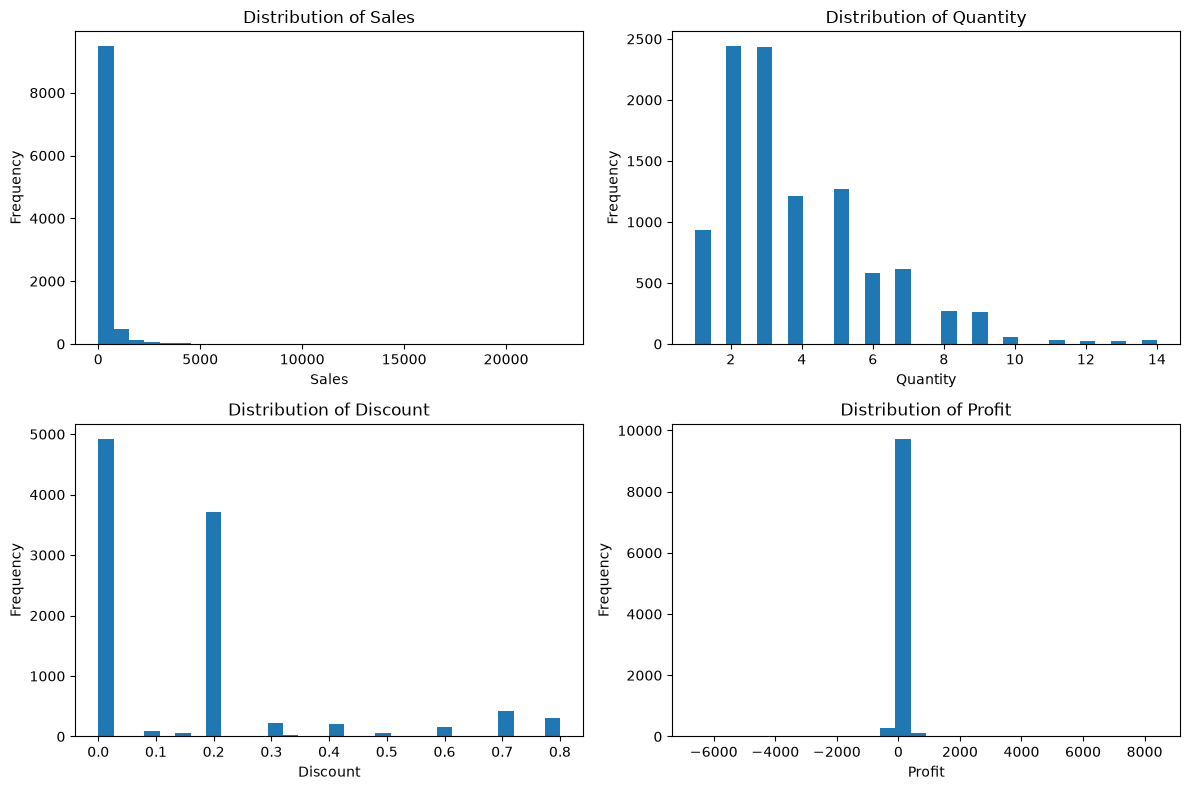

In [134]:
# Visualize Sales, Quantity, Discount, Profit
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, numerical_cols):
    ax.hist(df[col], bins=30)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

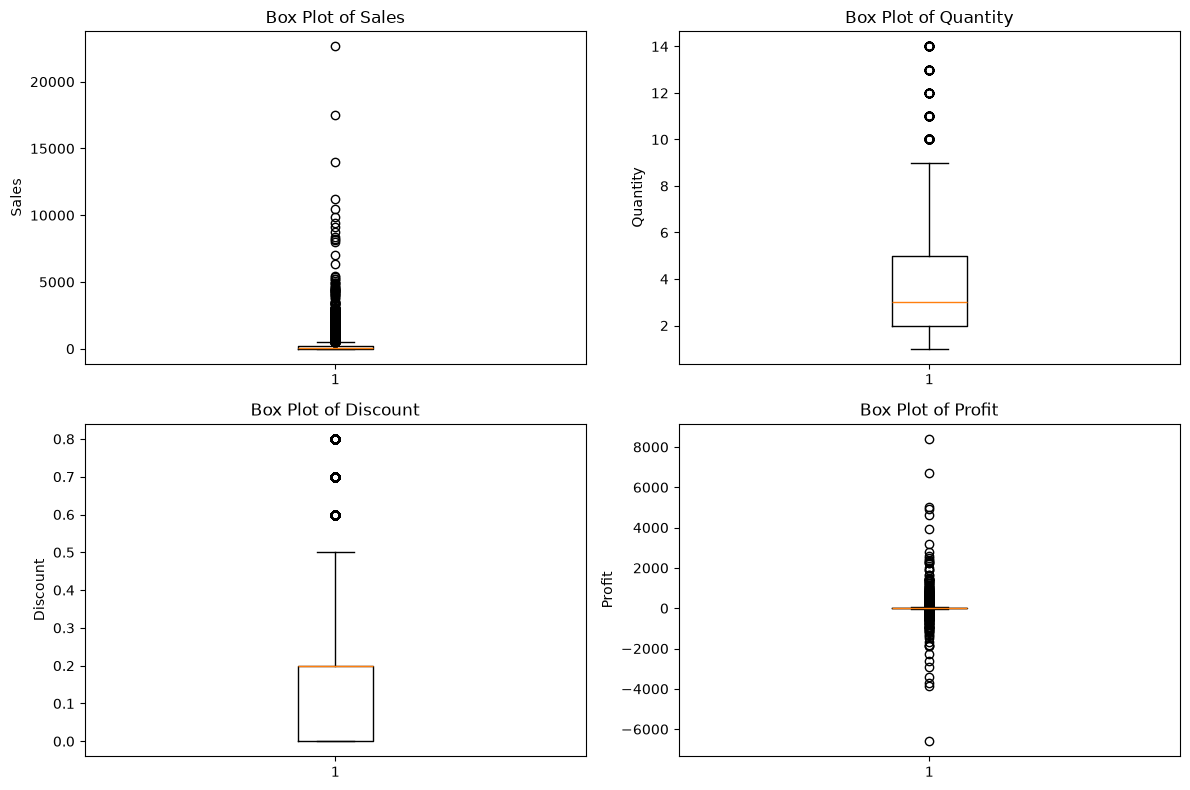

In [135]:
# Visualize the spread and potential outliers in numerical variables
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, numerical_cols):
    ax.boxplot(df[col])
    ax.set_title(f"Box Plot of {col}")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

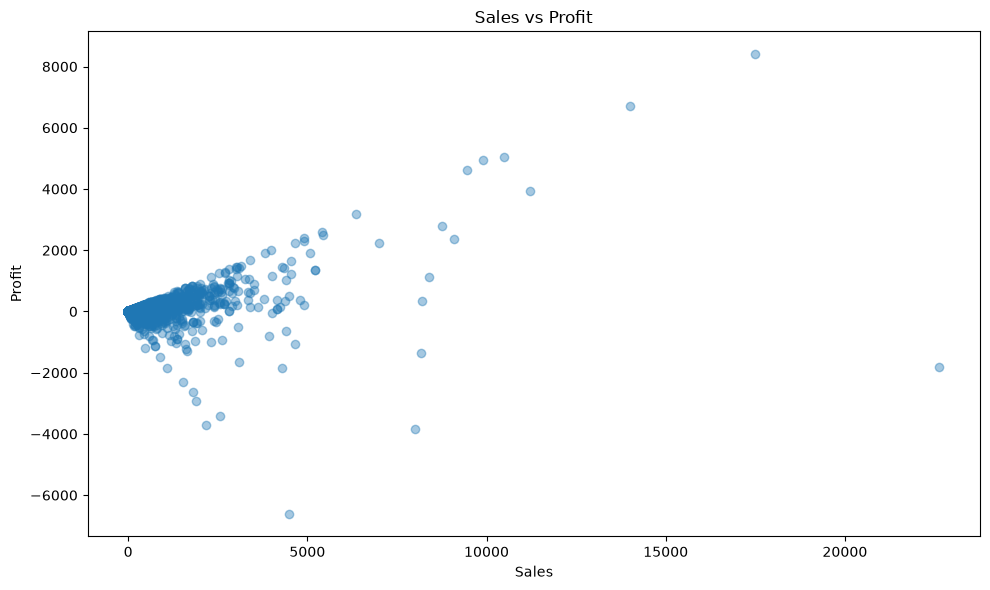

In [136]:
# Examine the relationship between Sales and Profit
plt.figure(figsize=(10, 6))

plt.scatter(df["Sales"], df["Profit"], alpha=0.4)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [137]:
# Calculate the Pearson correlation between Sales and Profit
sales_profit_corr = df["Sales"].corr(df["Profit"])

print("Pearson correlation between Sales and Profit:", sales_profit_corr)

Pearson correlation between Sales and Profit: 0.48145972301923856


In [138]:
# Calculate the Spearman correlation between Sales and Profit
sales_profit_spearman = df["Sales"].corr(df["Profit"], method="spearman")

print("Spearman correlation between Sales and Profit:", sales_profit_spearman)

Spearman correlation between Sales and Profit: 0.5203720312945255


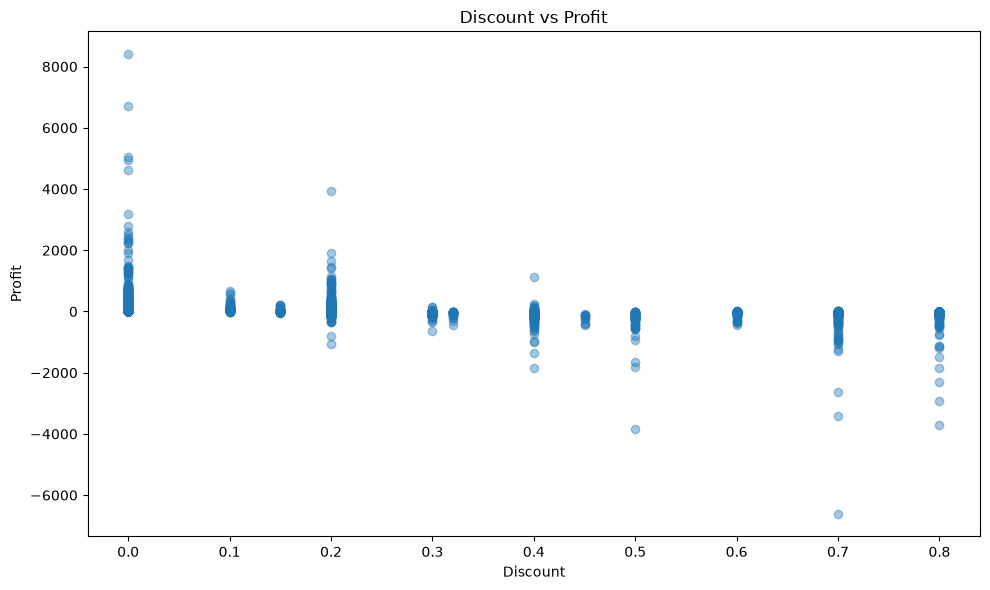

In [139]:
# Examine the relationship between Discount and Profit
plt.figure(figsize=(10, 6))

plt.scatter(df["Discount"], df["Profit"], alpha=0.4)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [140]:
# Calculate Pearson and Spearman correlations between Discount and Profit
discount_profit_pearson = df["Discount"].corr(df["Profit"])
discount_profit_spearman = df["Discount"].corr(df["Profit"], method="spearman")

print("Pearson correlation between Discount and Profit:", discount_profit_pearson)
print("Spearman correlation between Discount and Profit:", discount_profit_spearman)

Pearson correlation between Discount and Profit: -0.21888187168877116
Spearman correlation between Discount and Profit: -0.5414893515331073


In [141]:
# Compare sales and profitability across different discount levels
discount_analysis = (
    df.groupby("Discount").agg(
        Transactions=("Discount", "size"),
        Average_Sales=("Sales", "mean"),
        Average_Profit=("Profit", "mean"),
        Total_Profit=("Profit", "sum")
    ).reset_index()
)

discount_analysis

,Discount,Transactions,Average_Sales,Average_Profit,Total_Profit
0,0.00,4925,224.431226,66.338799,326718.5872
1,0.10,96,572.421844,94.791354,9099.9700
2,0.15,52,529.971567,27.288298,1418.9915
3,0.20,3706,208.834160,24.576350,91079.9517
4,0.30,230,454.235074,-45.710633,-10513.4456
5,0.32,27,536.794770,-88.560656,-2391.1377
6,0.40,207,562.791101,-111.528378,-23086.3742
7,0.45,11,498.634000,-226.646464,-2493.1111
8,0.50,66,892.705152,-310.703456,-20506.4281
9,0.60,149,47.690872,-41.371458,-6164.3472


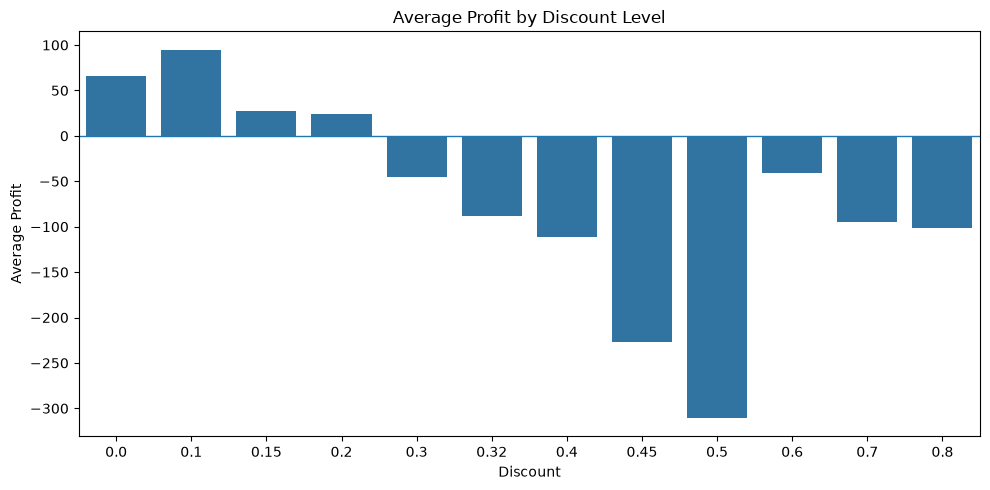

In [142]:
# Visualize average profit across different discount levels
plt.figure(figsize=(10, 5))

sns.barplot(
    data=discount_analysis,
    x="Discount",
    y="Average_Profit"
)

plt.axhline(0, linewidth=1)
plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### Discount & Profit — Observations

The analysis of average profit across different discount levels reveals a strong relationship between discounting and profitability.

- Transactions with **0% discount** generate an average profit of approximately **66.34**.
- A **10% discount** has the highest average profit at approximately **94.79**, suggesting that a small discount may help maintain or improve profitability in certain transactions.
- Average profit decreases substantially at **15% and 20% discount levels**, falling to approximately **27.29** and **24.58**, respectively.
- From a **30% discount level onward, average profit becomes negative**, indicating that higher discounts are associated with loss-making transactions.
- The **50% discount level shows the lowest average profit**, at approximately **-310.70**.
- High discount levels such as **70% and 80%** also result in substantial negative average profits.
- Some discount levels have relatively few transactions, such as **32% and 45%**, so their average profit values should be interpreted cautiously.

Overall, the analysis suggests that **higher discounting can significantly reduce profitability**, with discounts of 30% or more appearing particularly unfavorable in this dataset.

This finding supports the earlier correlation analysis, where Discount and Profit showed a negative relationship. However, correlation alone does not establish causation, so the discount analysis should be further examined alongside product, category, and regional performance.

In [143]:
# Analyze sales and profit performance by category

category_analysis = (
    df.groupby("Category").agg(
        Transactions=("Order ID", "count"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Average_Sales=("Sales", "mean"),
        Average_Profit=("Profit", "mean")
      ).sort_values("Total_Sales", ascending=False)
)

category_analysis

,Transactions,Total_Sales,Total_Profit,Average_Sales,Average_Profit
Category,,,,,
Technology,1865,839893.2790,146543.3756,450.344922,78.575537
Furniture,2201,754747.7613,19729.9956,342.911295,8.964105
Office Supplies,6128,731893.3140,126023.4434,119.434288,20.565183


In [144]:
# Analyze sales and profit performance by sub-category

subcategory_analysis = (
    df.groupby("Sub-Category")
      .agg(
          Transactions=("Order ID", "count"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Average_Sales=("Sales", "mean"),
          Average_Profit=("Profit", "mean")
      )
      .sort_values("Total_Profit", ascending=False)
)

subcategory_analysis

,Transactions,Total_Sales,Total_Profit,Average_Sales,Average_Profit
Sub-Category,,,,,
Copiers,70,150745.2900,56093.9365,2153.504143,801.341950
Phones,903,331842.6400,45050.8265,367.489081,49.890173
Accessories,775,167380.3180,41936.6357,215.974604,54.111788
Paper,1384,79540.5380,34511.5070,57.471487,24.936060
Binders,1548,207354.8810,31426.1003,133.950182,20.301098
Chairs,634,335768.2490,27223.5323,529.602916,42.939325
Storage,856,224644.5540,21285.1115,262.435227,24.865784
Appliances,474,108213.1850,18329.4844,228.297859,38.669798
Furnishings,1009,95598.1260,13891.7430,94.745417,13.767833


In [145]:
# Identify the most and least profitable sub-categories

top_subcategories = subcategory_analysis.nlargest(5, "Total_Profit")
bottom_subcategories = subcategory_analysis.nsmallest(5, "Total_Profit")

print("Top 5 Most Profitable Sub-Categories")
display(top_subcategories)

print("\nBottom 5 Least Profitable Sub-Categories")
display(bottom_subcategories)

Top 5 Most Profitable Sub-Categories


,Transactions,Total_Sales,Total_Profit,Average_Sales,Average_Profit
Sub-Category,,,,,
Copiers,70,150745.290,56093.9365,2153.504143,801.341950
Phones,903,331842.640,45050.8265,367.489081,49.890173
Accessories,775,167380.318,41936.6357,215.974604,54.111788
Paper,1384,79540.538,34511.5070,57.471487,24.936060
Binders,1548,207354.881,31426.1003,133.950182,20.301098



Bottom 5 Least Profitable Sub-Categories


,Transactions,Total_Sales,Total_Profit,Average_Sales,Average_Profit
Sub-Category,,,,,
Tables,326,208020.1820,-17753.2061,638.098718,-54.457687
Bookcases,232,115361.2043,-3632.0736,497.246570,-15.655490
Supplies,192,46725.4980,-1171.3945,243.361969,-6.101013
Fasteners,229,8532.2400,2428.6358,37.258690,10.605397
Machines,117,189925.0310,3461.9769,1623.290863,29.589546


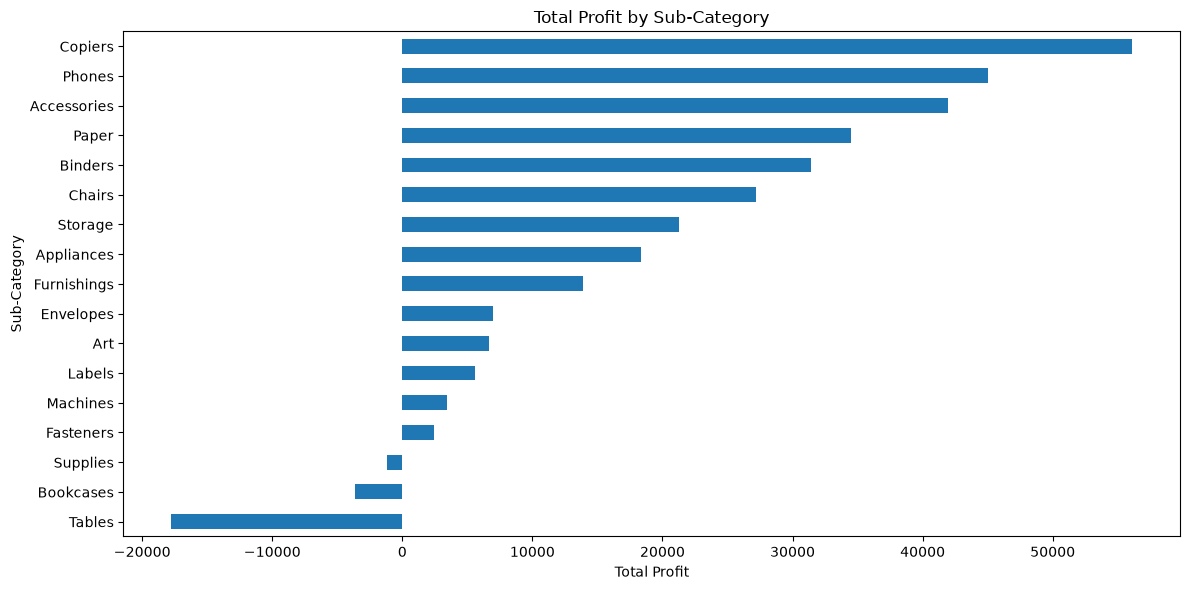

In [146]:
# Visualize total profit by sub-category

plt.figure(figsize=(12, 6))

subcategory_analysis["Total_Profit"].sort_values().plot(kind="barh")

plt.title("Total Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

### Category & Sub-Category Analysis — Observations

The category and sub-category analysis shows that sales volume and profitability do not always move together.

- **Technology** is the strongest overall category, generating the highest total sales and total profit despite having the fewest transactions among the three categories.
- **Office Supplies** has the highest transaction volume, with 6,128 transactions, but its average sales per transaction are considerably lower than Technology and Furniture.
- **Furniture** generates substantial sales but produces significantly lower total profit than Technology and Office Supplies, indicating weaker profitability.
- At the sub-category level, **Copiers** are the strongest performer, generating approximately 56,093.94 in total profit from only 70 transactions. Its average profit per transaction is approximately 801.34.
- **Phones** and **Accessories** are also major contributors to total profitability.
- **Tables** are the weakest-performing sub-category, generating approximately 208,020.18 in sales but producing a total loss of approximately 17,753.21.
- **Bookcases** and **Supplies** also generate negative total profit.
- **Machines** have very high average sales but relatively modest total profit, demonstrating that high-value transactions do not necessarily translate into high profitability.

Overall, the analysis indicates that **revenue alone is not sufficient for evaluating product performance**. Profitability must be considered alongside sales volume and transaction frequency.

The loss-making sub-categories, particularly Tables, Bookcases, and Supplies, should be investigated further using discount, regional, and time-based analysis before making business decisions.

In [147]:
# Analyze sales and profit performance by region

region_analysis = (
    df.groupby("Region")
      .agg(
          Transactions=("Order ID", "count"),
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Average_Sales=("Sales", "mean"),
          Average_Profit=("Profit", "mean")
      )
      .sort_values("Total_Profit", ascending=False)
)

region_analysis

,Transactions,Total_Sales,Total_Profit,Average_Sales,Average_Profit
Region,,,,,
West,3253,739813.6085,110798.8170,227.425026,34.060503
East,2986,691828.1680,94883.2603,231.690612,31.776042
South,1620,391721.9050,46749.4303,241.803645,28.857673
Central,2335,503170.6728,39865.3070,215.490652,17.072937


In [148]:
# Calculate profit margin for each region

region_analysis["Profit_Margin_%"] = (
    region_analysis["Total_Profit"] /
    region_analysis["Total_Sales"] * 100
)

region_analysis

,Transactions,Total_Sales,Total_Profit,Average_Sales,Average_Profit,Profit_Margin_%
Region,,,,,,
West,3253,739813.6085,110798.8170,227.425026,34.060503,14.976585
East,2986,691828.1680,94883.2603,231.690612,31.776042,13.714859
South,1620,391721.9050,46749.4303,241.803645,28.857673,11.934342
Central,2335,503170.6728,39865.3070,215.490652,17.072937,7.922820


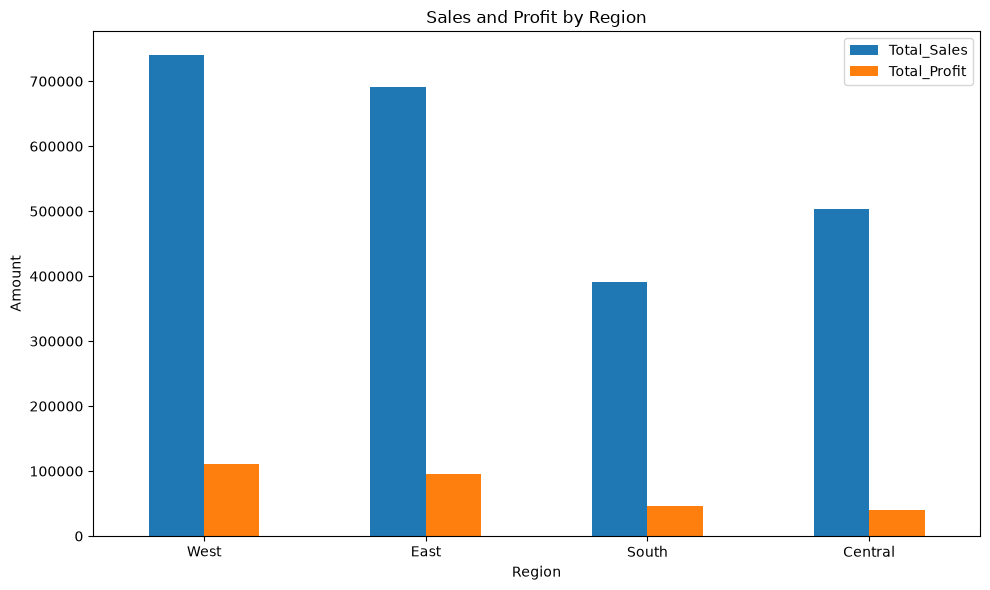

In [149]:
# Compare total sales and total profit across regions

region_analysis[["Total_Sales", "Total_Profit"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [150]:
# Create year and month columns from Order Date

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()

In [151]:
# Check the number of transactions in each year

df["Year"].value_counts().sort_index()

Year
2023    2051
2024    2130
2025    2634
2026    3379
Name: count, dtype: int64

In [152]:
# Calculate total sales and profit for each year

yearly_analysis = df.groupby("Year").agg(
    Transactions=("Order ID", "count"),
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Average_Sales=("Sales", "mean"),
    Average_Profit=("Profit", "mean")
)

yearly_analysis

,Transactions,Total_Sales,Total_Profit,Average_Sales,Average_Profit
Year,,,,,
2023,2051,494040.2121,51684.2957,240.877724,25.199559
2024,2130,472993.0310,62020.9695,222.062456,29.117826
2025,2634,613933.5800,82665.2018,233.080326,31.383903
2026,3379,745567.5312,95926.3476,220.647390,28.388975


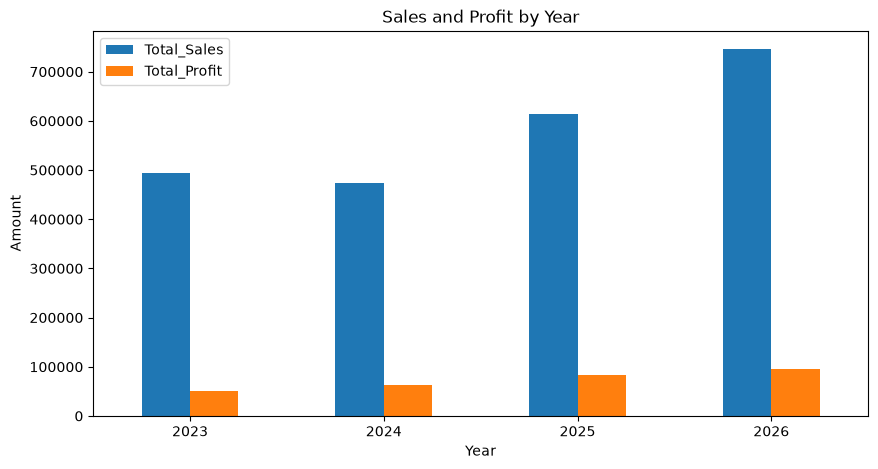

In [153]:
# Visualize total sales and profit by year

yearly_analysis[["Total_Sales", "Total_Profit"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Sales and Profit by Year")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend()
plt.show()

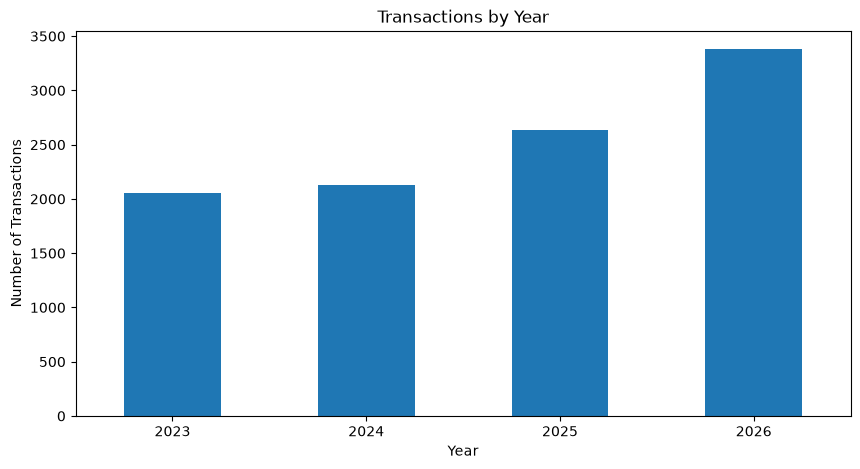

In [154]:
# Visualize transaction volume by year

yearly_analysis["Transactions"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Transactions by Year")
plt.xlabel("Year")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

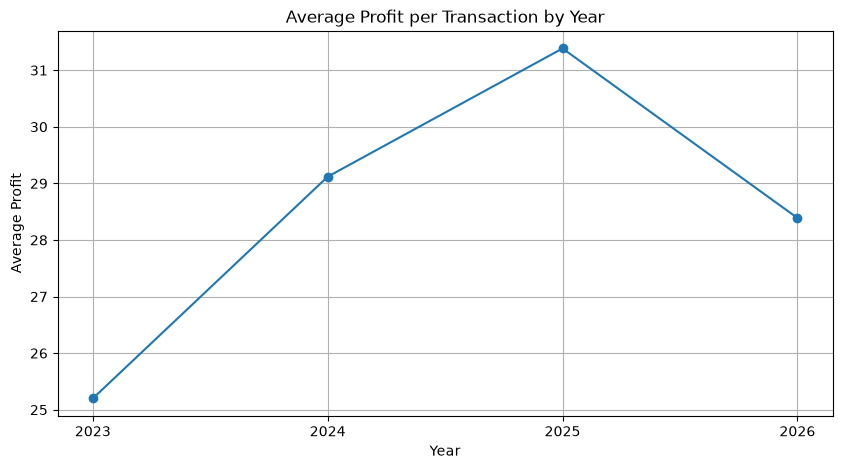

In [155]:
# Visualize average profit per transaction by year

yearly_analysis["Average_Profit"].plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Average Profit per Transaction by Year")
plt.xlabel("Year")
plt.ylabel("Average Profit")
plt.xticks(yearly_analysis.index)
plt.grid(True)
plt.show()

In [156]:
# Calculate year-over-year growth in sales and profit

yearly_analysis["Sales_Growth_%"] = yearly_analysis["Total_Sales"].pct_change() * 100
yearly_analysis["Profit_Growth_%"] = yearly_analysis["Total_Profit"].pct_change() * 100

yearly_analysis

,Transactions,Total_Sales,Total_Profit,Average_Sales,Average_Profit,Sales_Growth_%,Profit_Growth_%
Year,,,,,,,
2023,2051,494040.2121,51684.2957,240.877724,25.199559,NaN,NaN
2024,2130,472993.0310,62020.9695,222.062456,29.117826,-4.260216,19.999641
2025,2634,613933.5800,82665.2018,233.080326,31.383903,29.797595,33.285891
2026,3379,745567.5312,95926.3476,220.647390,28.388975,21.441074,16.041993


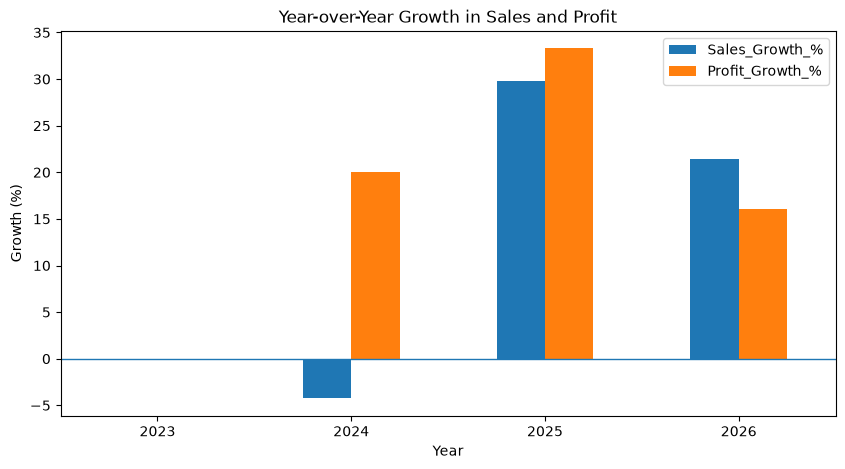

In [157]:
# Visualize year-over-year sales and profit growth

yearly_analysis[["Sales_Growth_%", "Profit_Growth_%"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Year-over-Year Growth in Sales and Profit")
plt.xlabel("Year")
plt.ylabel("Growth (%)")
plt.xticks(rotation=0)
plt.axhline(0, linewidth=1)
plt.legend()
plt.show()

In [158]:
# Calculate monthly sales and profit

monthly_analysis = df.groupby(["Year", "Month"]).agg(
    Transactions=("Order ID", "count"),
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
).reset_index()

monthly_analysis.head()

,Year,Month,Transactions,Total_Sales,Total_Profit
0,2023,1,84,14518.055,2539.3907
1,2023,2,46,4519.892,862.3084
2,2023,3,159,56933.909,693.4499
3,2023,4,135,28295.345,3488.8352
4,2023,5,132,26319.767,3196.3918


In [159]:
# Create a proper date column for monthly trend analysis

monthly_analysis["Year_Month"] = pd.to_datetime(
    monthly_analysis["Year"].astype(str) + "-" +
    monthly_analysis["Month"].astype(str) + "-01"
)

monthly_analysis = monthly_analysis.sort_values("Year_Month")

monthly_analysis.head()

,Year,Month,Transactions,Total_Sales,Total_Profit,Year_Month
0,2023,1,84,14518.055,2539.3907,2023-01-01
1,2023,2,46,4519.892,862.3084,2023-02-01
2,2023,3,159,56933.909,693.4499,2023-03-01
3,2023,4,135,28295.345,3488.8352,2023-04-01
4,2023,5,132,26319.767,3196.3918,2023-05-01


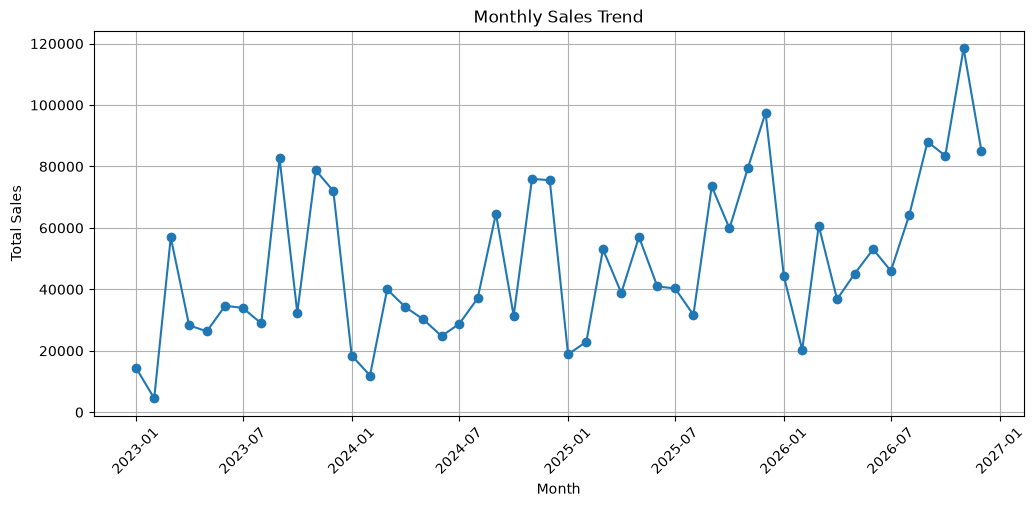

In [160]:
# Visualize monthly sales trend

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis["Year_Month"],
    monthly_analysis["Total_Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

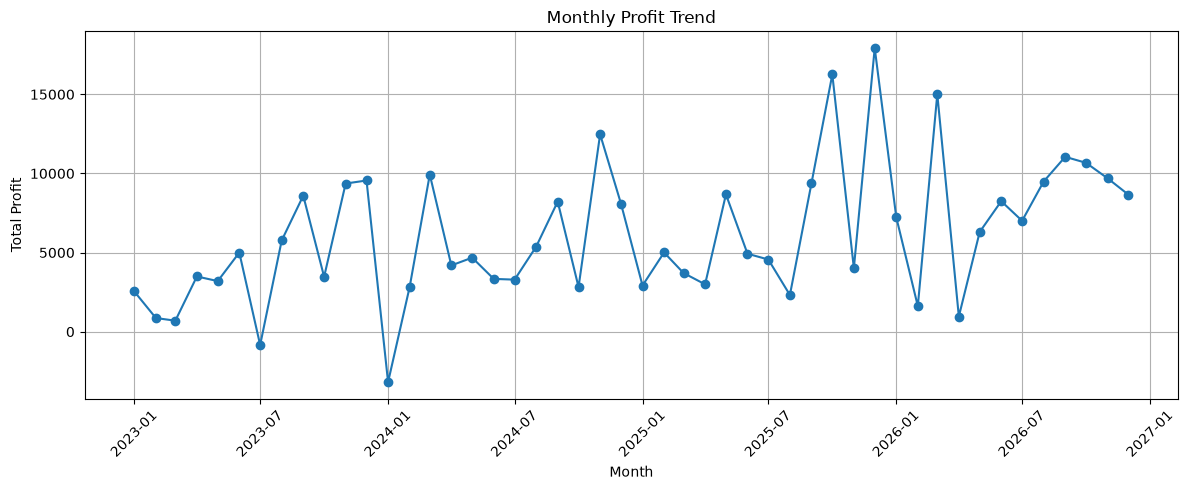

In [161]:
# Analyse the monthly profit trend

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis["Year_Month"],
    monthly_analysis["Total_Profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

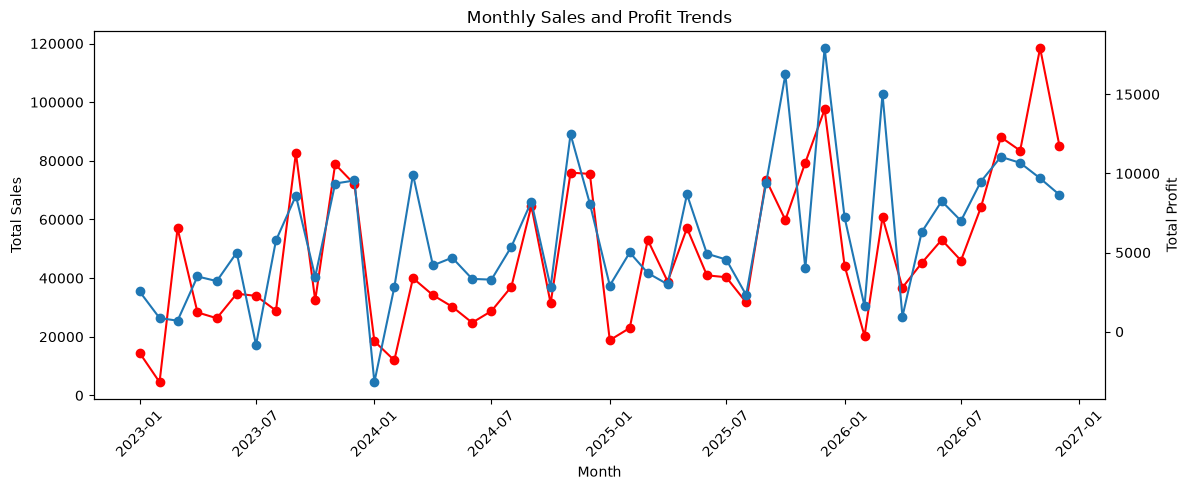

In [162]:
# Compare monthly sales and profit trends

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    monthly_analysis["Year_Month"],
    monthly_analysis["Total_Sales"],
    marker="o",
    label="Total Sales", 
    color="red"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Total Sales")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    monthly_analysis["Year_Month"],
    monthly_analysis["Total_Profit"],
    marker="o",
    label="Total Profit"
)

ax2.set_ylabel("Total Profit")

plt.title("Monthly Sales and Profit Trends")
plt.tight_layout()
plt.show()

In [163]:
# Identify the highest and lowest performing months

top_sales_months = monthly_analysis.nlargest(5, "Total_Sales")

bottom_sales_months = monthly_analysis.nsmallest(5, "Total_Sales")

top_profit_months = monthly_analysis.nlargest(5, "Total_Profit")

bottom_profit_months = monthly_analysis.nsmallest(5, "Total_Profit")

print("Top 5 Months by Sales:")
display(top_sales_months)

print("\nBottom 5 Months by Sales:")
display(bottom_sales_months)

print("\nTop 5 Months by Profit:")
display(top_profit_months)

print("\nBottom 5 Months by Profit:")
display(bottom_profit_months)

Top 5 Months by Sales:


,Year,Month,Transactions,Total_Sales,Total_Profit,Year_Month
46,2026,11,460,118454.5050,9692.1037,2026-11-01
35,2025,12,366,97502.2770,17926.3013,2025-12-01
44,2026,9,465,88064.5320,11050.8024,2026-09-01
47,2026,12,482,85175.0328,8655.8269,2026-12-01
45,2026,10,309,83474.7832,10670.5312,2026-10-01



Bottom 5 Months by Sales:


,Year,Month,Transactions,Total_Sales,Total_Profit,Year_Month
1,2023,2,46,4519.8920,862.3084,2023-02-01
13,2024,2,64,11951.4110,2813.8508,2024-02-01
0,2023,1,84,14518.0550,2539.3907,2023-01-01
12,2024,1,64,18461.9156,-3189.8030,2024-01-01
24,2025,1,95,18830.3310,2916.0233,2025-01-01



Top 5 Months by Profit:


,Year,Month,Transactions,Total_Sales,Total_Profit,Year_Month
35,2025,12,366,97502.2770,17926.3013,2025-12-01
33,2025,10,199,59831.0010,16256.8422,2025-10-01
38,2026,3,245,60728.4808,15013.0910,2026-03-01
22,2024,11,324,75972.5635,12474.7884,2024-11-01
44,2026,9,465,88064.5320,11050.8024,2026-09-01



Bottom 5 Months by Profit:


,Year,Month,Transactions,Total_Sales,Total_Profit,Year_Month
12,2024,1,64,18461.9156,-3189.8030,2024-01-01
6,2023,7,143,33946.3930,-841.4826,2023-07-01
2,2023,3,159,56933.9090,693.4499,2023-03-01
1,2023,2,46,4519.8920,862.3084,2023-02-01
39,2026,4,204,36779.0361,957.5300,2026-04-01


### Time-Based Analysis — Observations

The monthly analysis was performed to examine changes in sales and profitability over time and identify periods of unusually high or low business performance.

- Monthly sales show substantial fluctuations throughout the period, with repeated peaks and declines rather than a smooth trend.
- The highest monthly sales were recorded in **November 2026**, with approximately **$118,454.51** in sales.
- The highest monthly profit was recorded in **December 2025**, with approximately **$17,926.30** in profit.
- High sales do not always correspond to proportionally high profit. For example, November 2026 generated the highest sales but its profit was lower than the profit generated in December 2025.
- **January 2024** recorded the lowest monthly profit at approximately **−$3,189.80**, despite generating approximately **$18,461.92** in sales.
- Several months recorded relatively low sales, particularly during January and February, although this pattern is not sufficiently consistent across years to establish a definitive seasonal effect.
- Most months generated positive profit, but a small number of periods experienced negative or very low profitability.
- The monthly sales and profit trends generally move in the same direction during several periods, but the relationship is not consistent across all months.
- These findings are consistent with the earlier correlation analysis, which showed a **moderate positive relationship between Sales and Profit** rather than a strong direct relationship.

Overall, the business shows considerable month-to-month variation in both sales and profitability. **Sales volume alone does not determine business performance**, highlighting the importance of analysing profitability alongside sales when evaluating monthly performance.

No definitive seasonal pattern is concluded at this stage because the available data covers only a limited number of years and monthly performance varies considerably across years.

In [164]:
# Analyse sales and profit performance by customer segment

segment_analysis = df.groupby("Segment").agg(
    Transactions=("Order ID", "count"),
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Average_Sales=("Sales", "mean"),
    Average_Profit=("Profit", "mean")
)

segment_analysis

,Transactions,Total_Sales,Total_Profit,Average_Sales,Average_Profit
Segment,,,,,
Consumer,5281,1.170660e+06,136371.4463,221.673885,25.823035
Corporate,3090,7.158061e+05,94249.6400,231.652471,30.501502
Home Office,1823,4.400684e+05,61675.7283,241.397933,33.831996


In [165]:
# Calculate profit margin for each customer segment

segment_analysis["Profit_Margin_%"] = (
    segment_analysis["Total_Profit"] /
    segment_analysis["Total_Sales"]
) * 100

segment_analysis.sort_values("Total_Profit", ascending=False)

,Transactions,Total_Sales,Total_Profit,Average_Sales,Average_Profit,Profit_Margin_%
Segment,,,,,,
Consumer,5281,1.170660e+06,136371.4463,221.673885,25.823035,11.649110
Corporate,3090,7.158061e+05,94249.6400,231.652471,30.501502,13.166923
Home Office,1823,4.400684e+05,61675.7283,241.397933,33.831996,14.015031


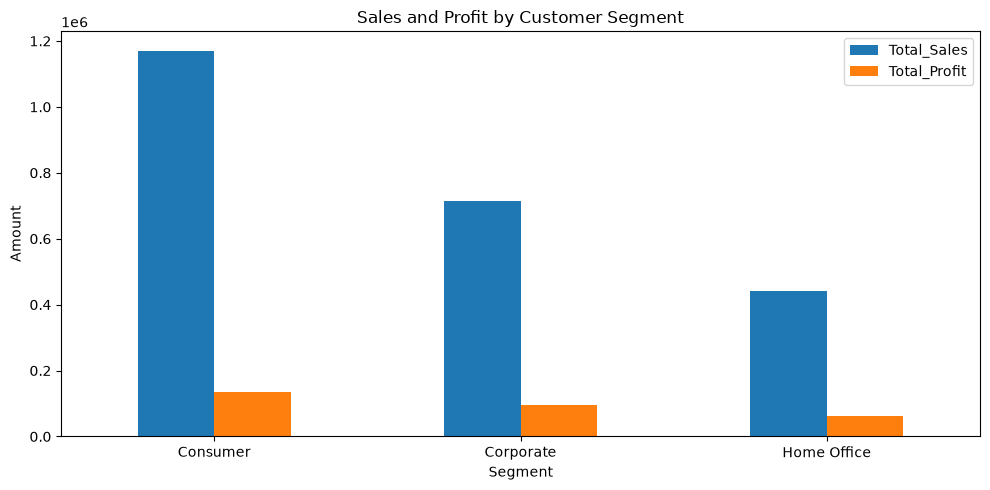

In [166]:
# Visualize total sales and profit by customer segment

segment_analysis[["Total_Sales", "Total_Profit"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [167]:
# Analyze sales and profit by shipping mode

shipping_analysis = df.groupby("Ship Mode").agg(
    Transactions=("Order ID", "count"),
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Average_Sales=("Sales", "mean"),
    Average_Profit=("Profit", "mean")
)

# Calculate profit margin
shipping_analysis["Profit_Margin_%"] = (
    shipping_analysis["Total_Profit"] /
    shipping_analysis["Total_Sales"]
) * 100

shipping_analysis = shipping_analysis.sort_values(
    "Total_Profit",
    ascending=False
)

shipping_analysis

,Transactions,Total_Sales,Total_Profit,Average_Sales,Average_Profit,Profit_Margin_%
Ship Mode,,,,,,
Standard Class,6120,1.378841e+06,168161.2095,225.300744,27.477322,12.195842
Second Class,1979,4.666711e+05,58962.1329,235.811577,29.793902,12.634622
First Class,1548,3.517507e+05,49012.7242,227.229158,31.661967,13.933936
Same Day,547,1.292720e+05,16160.7480,236.328985,29.544329,12.501357


In [168]:
# Customer-level analysis

customer_analysis = df.groupby("Customer Name").agg(
    Transactions=("Order ID", "count"),
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Average_Sales=("Sales", "mean"),
    Average_Profit=("Profit", "mean")
)

customer_analysis["Profit_Margin_%"] = (
    customer_analysis["Total_Profit"] /
    customer_analysis["Total_Sales"]
) * 100

customer_analysis = customer_analysis.sort_values(
    "Total_Sales",
    ascending=False
)

customer_analysis.head(10)

,Transactions,Total_Sales,Total_Profit,Average_Sales,Average_Profit,Profit_Margin_%
Customer Name,,,,,,
Sean Miller,15,25043.050,-1980.7393,1669.536667,-132.049287,-7.909337
Tamara Chand,12,19052.218,8981.3239,1587.684833,748.443658,47.140569
Raymond Buch,18,15117.339,6976.0959,839.852167,387.560883,46.146322
Tom Ashbrook,10,14595.620,4703.7883,1459.562000,470.378830,32.227396
Adrian Barton,20,14473.571,5444.8055,723.678550,272.240275,37.618950
Ken Lonsdale,29,14175.229,806.8550,488.801000,27.822586,5.692007
Sanjit Chand,22,14142.334,5757.4119,642.833364,261.700541,40.710479
Hunter Lopez,11,12873.298,5622.4292,1170.299818,511.129927,43.675127
Sanjit Engle,19,12209.438,2650.6769,642.602000,139.509311,21.710065


In [170]:
# State-level analysis

state_analysis = df.groupby("State/Province").agg(
    Transactions=("Order ID", "count"),
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Average_Sales=("Sales", "mean"),
    Average_Profit=("Profit", "mean")
)

state_analysis["Profit_Margin_%"] = (
    state_analysis["Total_Profit"] /
    state_analysis["Total_Sales"]
) * 100

state_analysis = state_analysis.sort_values(
    "Total_Profit",
    ascending=False
)

state_analysis.head(10)

,Transactions,Total_Sales,Total_Profit,Average_Sales,Average_Profit,Profit_Margin_%
State/Province,,,,,,
California,2001,457687.6315,76381.3871,228.729451,38.171608,16.688541
New York,1128,310876.2710,74038.5486,275.599531,65.637011,23.816082
Washington,506,138641.2700,33402.6517,273.994605,66.013146,24.092863
Michigan,255,76269.6140,24463.1876,299.096525,95.934069,32.074618
Virginia,224,70636.7200,18597.9504,315.342500,83.026564,26.329012
Indiana,149,53555.3600,18382.9363,359.431946,123.375411,34.325110
Georgia,184,49095.8400,16250.0433,266.825217,88.315453,33.098615
Kentucky,139,36591.7500,11199.6966,263.250000,80.573357,30.607163
Minnesota,89,29863.1500,10823.1874,335.541011,121.608847,36.242618


In [171]:
# Correlation matrix for important numerical variables

correlation = df[
    ["Sales", "Quantity", "Discount", "Profit"]
].corr()

correlation

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.198457,-0.027756,0.481460
Quantity,0.198457,1.000000,0.007475,0.066145
Discount,-0.027756,0.007475,1.000000,-0.218882
Profit,0.481460,0.066145,-0.218882,1.000000


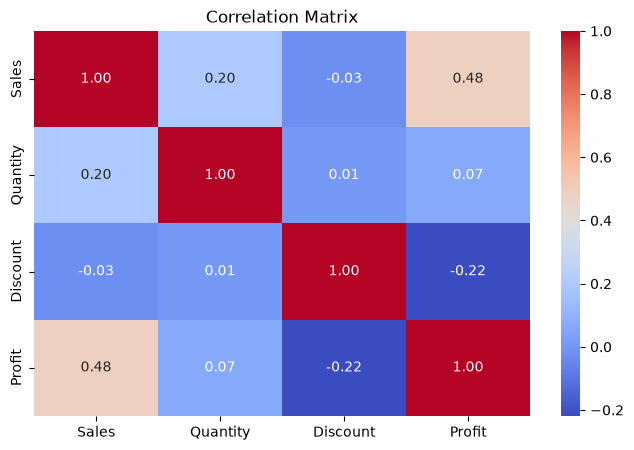

In [172]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()